In [1]:
import os
import sys

import mudata
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from qmplot import qqplot

In [20]:
guide_annotation_path  = "/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/guide/guide_metadata_v43.tsv"

df_target = pd.read_csv(guide_annotation_path, sep = "\t", index_col = 0)
df_target_non = df_target[df_target["targeting"] == False]
reference_targets = df_target_non.index.values.tolist()

In [21]:
# Load guide target
guide_target = pd.read_csv(guide_annotation_path, sep='\t')
non_targeting_idx = guide_target.index[guide_target.targeting==False]

guide_target = guide_target.loc[non_targeting_idx]

In [3]:
# Actual data
test_stats_real_df = []
for k in [30, 60, 80, 100, 200, 250, 300]:  

    # Run perturbation assocation
    for samp in ['D0', 'sample_D1', 'sample_D2', 'sample_D3']:
        test_stats_df_ = pd.read_csv('../240807_cNMF_eval_pipeline_analysis/{}/{}_perturbation_association_results_{}.txt'.format(k,k,samp), sep='\t')
        test_stats_df_['sample'] = samp
        test_stats_df_['K'] = k
        #test_stats_df_['fdr'] = fdrcorrection(test_stats_df_['pval'])[1]
        test_stats_real_df.append(test_stats_df_)
test_stats_real_df = pd.concat(test_stats_real_df, ignore_index=True)
test_stats_real_df['real'] = True

In [4]:
# # Calibrate tests using "fake_target guides"
# test_stats_dfs = []
# for i in range(10):

#     guide_target_ = guide_target.copy()
#     guide_target_.loc[guide_target_.OligoID.isin(np.random.choice(guide_target.OligoID, 15)), 'Target'] = 'targeting'

#     for k in [30, 60, 80, 100, 200, 250, 300]: # 400  

#         # Load mdata
#         mdata = mudata.read('../240701_cNMF/cNMF_{}_0.2_gene_names.h5mu'.format(k))  
#         mdata['cNMF'].obsm['guide_assignment'] = mdata['cNMF'].obsm['guide_assignment'][:, non_targeting_idx]
#         mdata['cNMF'].uns['guide_names'] = mdata['cNMF'].uns['guide_names'][non_targeting_idx]
#         mdata['cNMF'].uns['guide_targets'] = guide_target_.loc[guide_target_.OligoID==mdata['cNMF'].uns['guide_names'], 'Target'].values
        
#         # Run perturbation assocation
#         for samp in mdata['rna'].obs['sample'].unique():
#             mdata_ = mdata[mdata['rna'].obs['sample']==samp]
#             test_stats_df = compute_perturbation_association(mdata_, prog_key='cNMF', 
#                                                             collapse_targets=True,
#                                                             pseudobulk=False,
#                                                             reference_targets=('non-targeting'),
#                                                             n_jobs=-1, inplace=False)

#             test_stats_df['sample'] = samp
#             test_stats_df['K'] = k
#             test_stats_df['run'] = i
#             test_stats_dfs.append(test_stats_df)

# test_stats_dfs = pd.concat(test_stats_dfs)
# test_stats_dfs.to_csv('perturbation_association_calibration.txt', sep='\t', index=False)

test_stats_dfs = pd.read_csv('perturbation_association_calibration.txt', sep='\t')

In [5]:
# Merge
test_stats_dfs['real'] =False
test_stats_dfs = pd.concat([test_stats_real_df, test_stats_dfs])

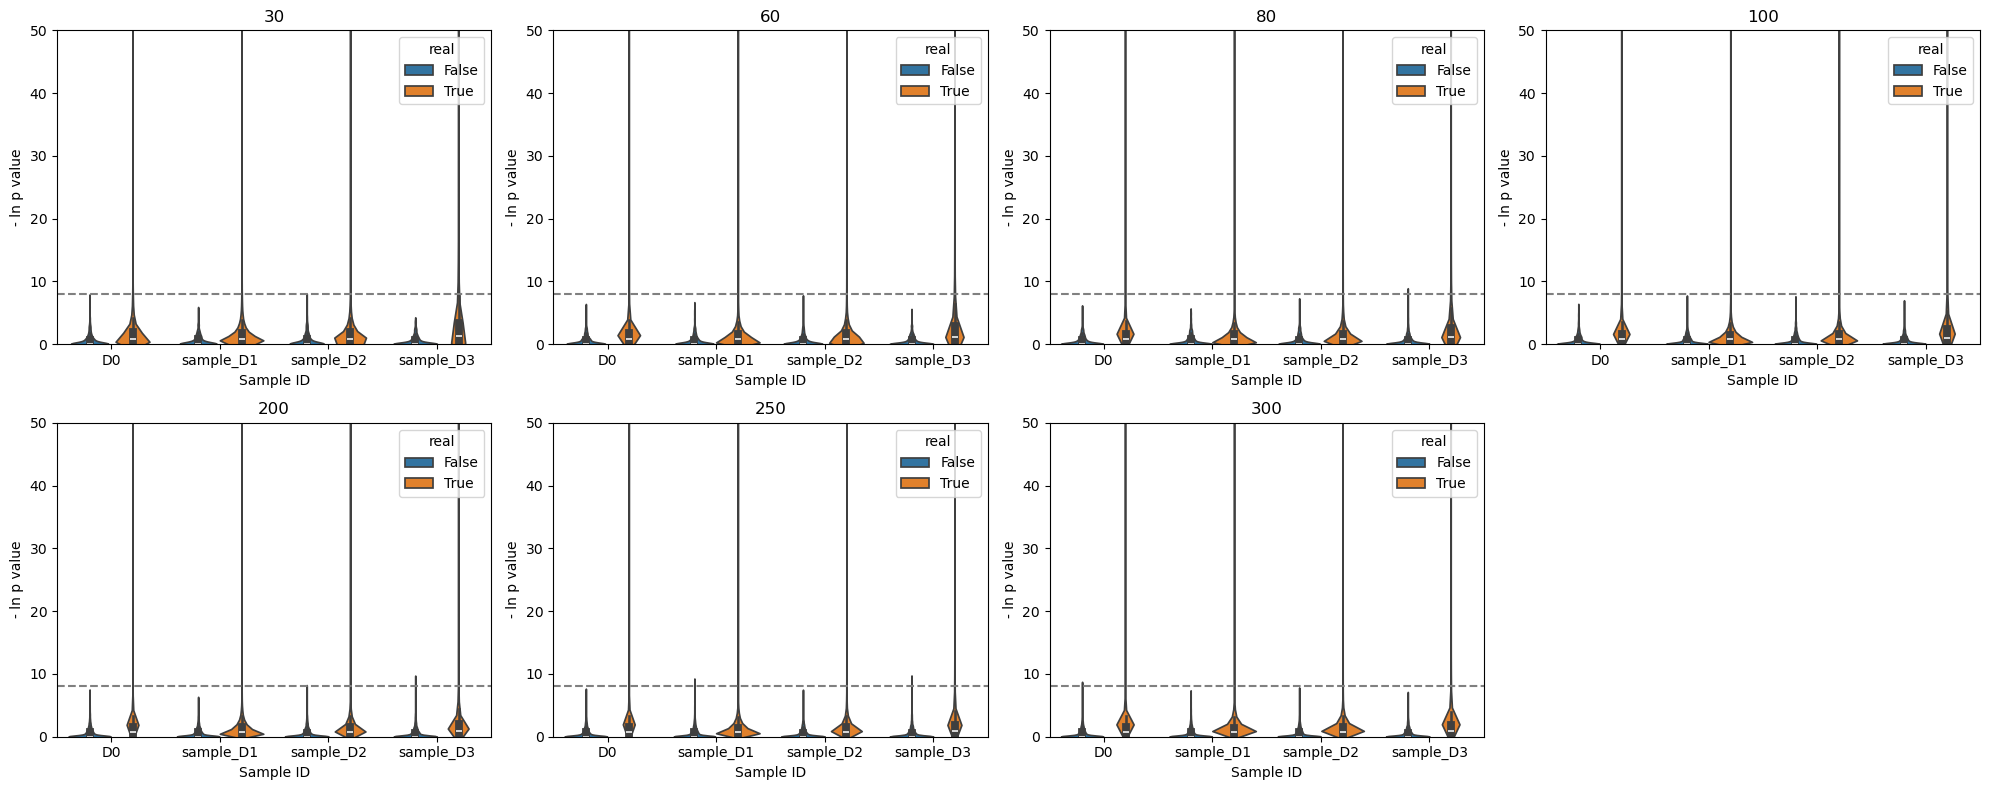

In [21]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20,8))
for i,k in enumerate([30, 60, 80, 100, 200, 250, 300]):

    test_stats_dfs['neg_log_pval'] = test_stats_dfs['pval'].apply(lambda x: -np.log(x))
    sns.violinplot(x='sample', y='neg_log_pval', hue='real', data=test_stats_dfs.loc[test_stats_dfs.K==k], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))
    axs.flat[i].set_xlabel('Sample ID')
    axs.flat[i].set_ylabel('- ln p value')
    axs.flat[i].set_ylim(0,50)
    axs.flat[i].axhline(8, color='grey', linestyle='dashed')

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig('perturbation_association_calibration.png', dpi=100)

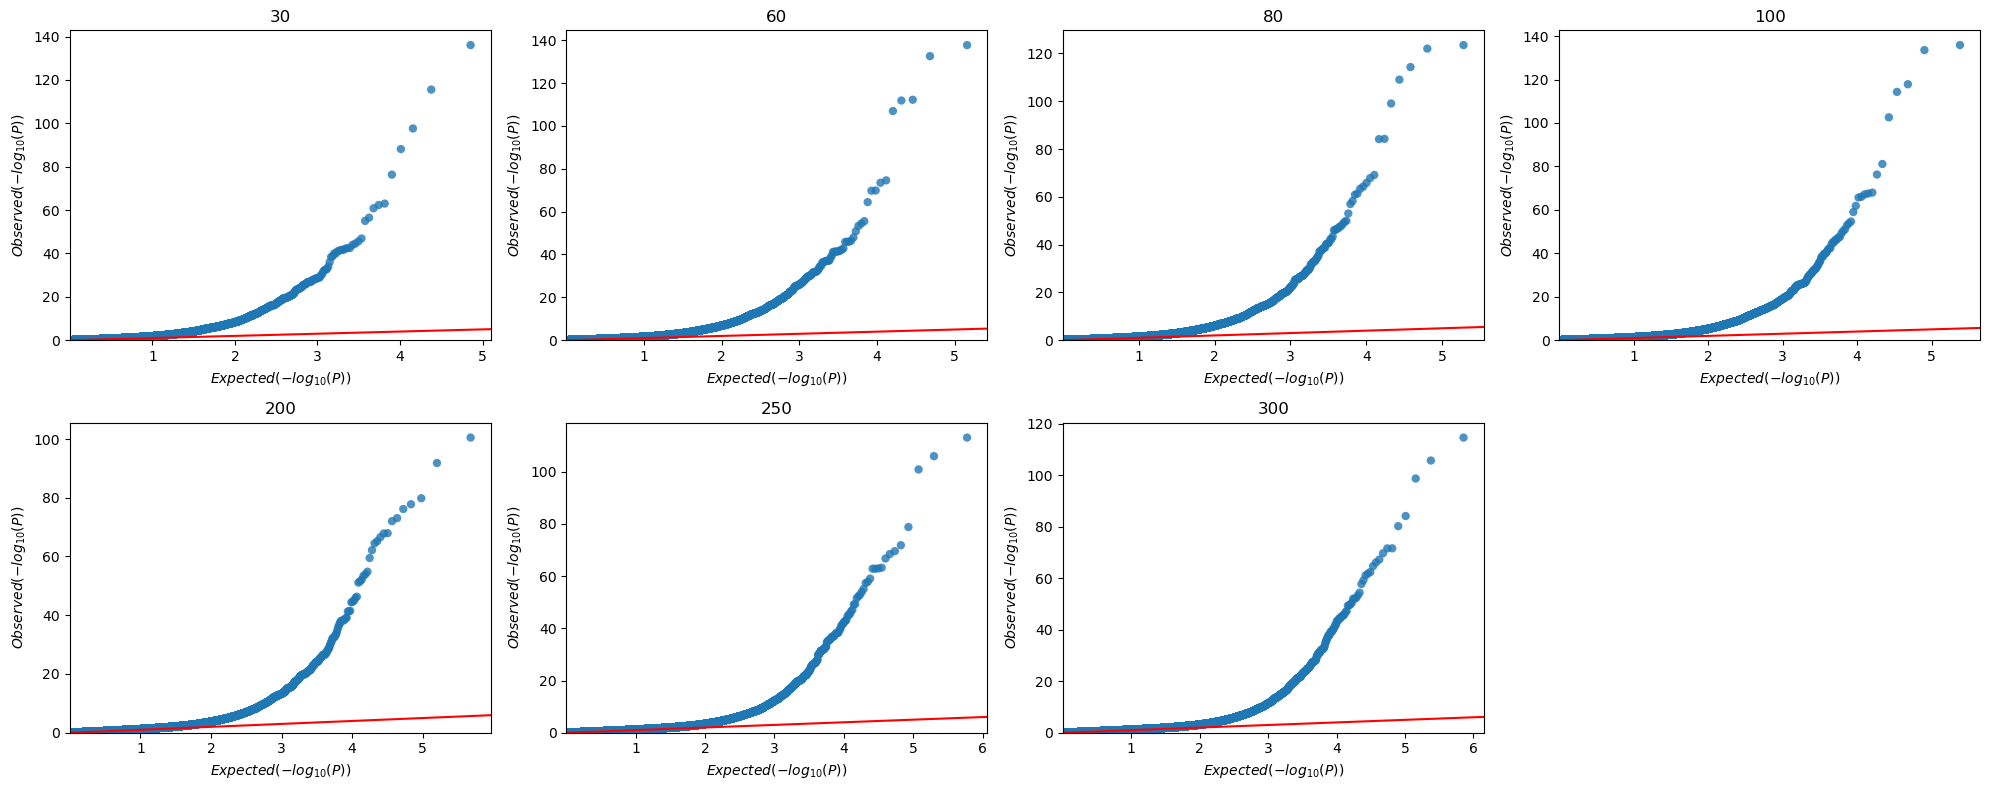

In [22]:
# QQ plot real
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20,8))
for i,k in enumerate([30, 60, 80, 100, 200, 250, 300]):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (test_stats_dfs.real==True), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig('perturbation_association_qqplot_real.png', dpi=100)

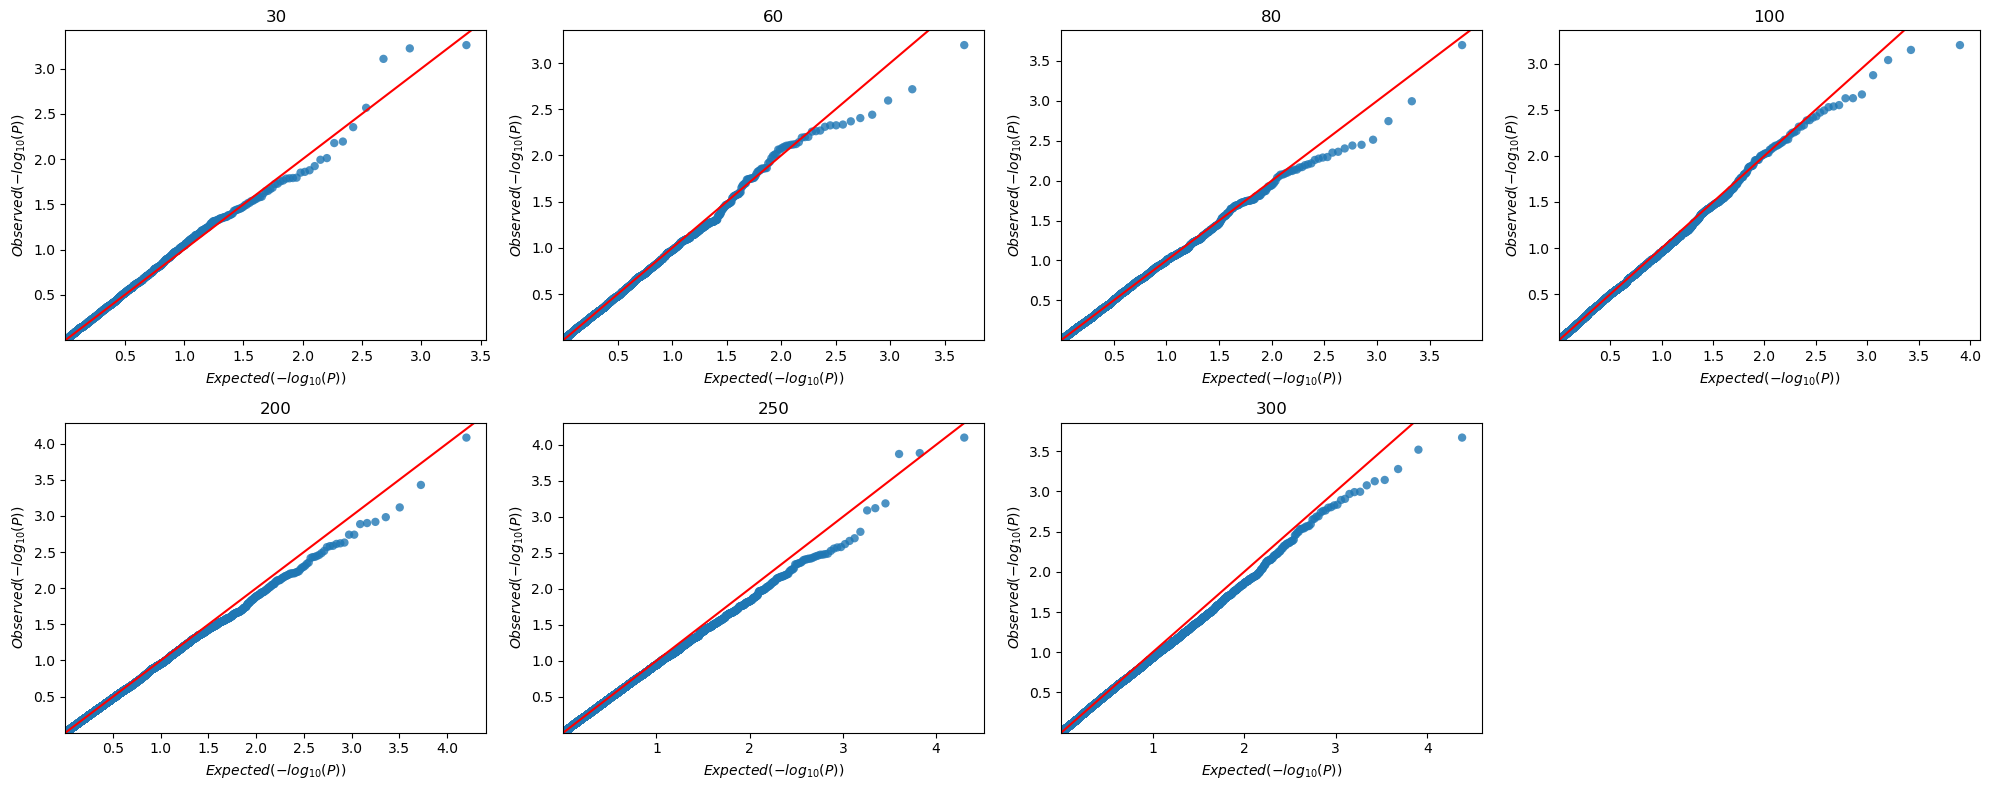

In [23]:
# QQ plot fake
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20,8))
for i,k in enumerate([30, 60, 80, 100, 200, 250, 300]):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (test_stats_dfs.real==False)& (test_stats_dfs.target_name=='targeting'), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig('perturbation_association_qqplot_null.png', dpi=100)